# Week 2 – Advanced Data Visualization and Storytelling with Python

**YUVA Data Science Internship**

**Intern:** Rishu Singh  
**Dataset:** Superstore Sales Dataset

## 1. Introduction

This notebook presents an advanced visual analysis of the Superstore Sales dataset. Building on the data acquisition, cleaning, and exploratory analysis completed in Week 1, this analysis focuses on transforming business data into meaningful visual stories.

The objective is to identify trends, relationships, profitability patterns, product-level performance, and regional differences using Python visualization libraries.

The analysis uses Pandas, NumPy, Matplotlib, and Seaborn for data processing and visualization.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load Week 1 dataset
file_path = Path("../dataset/superstore_sales.xls")
df = pd.read_excel(file_path)

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully!
Rows: 10194
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


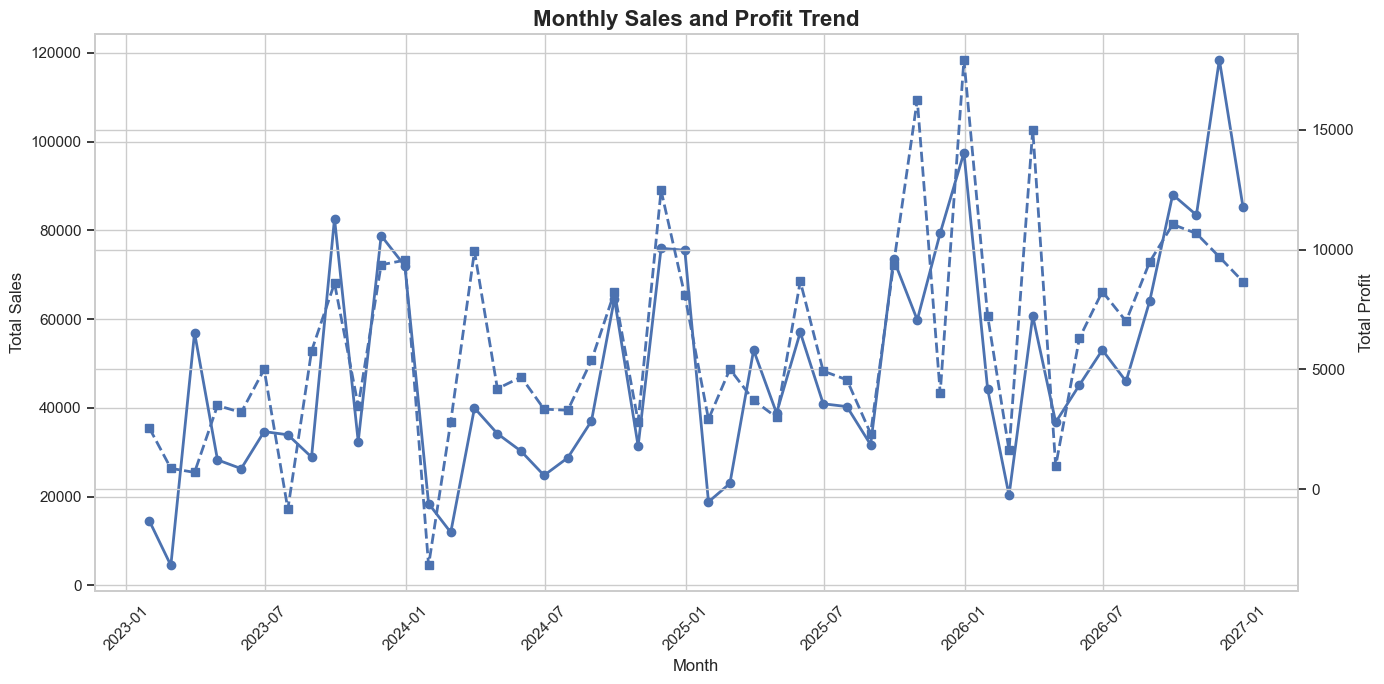

In [50]:
# ==========================================
# Visualization 1: Monthly Sales & Profit Trend
# ==========================================

# Create monthly summary
monthly_data = (
    df.set_index("Order Date")
      .resample("ME")[["Sales", "Profit"]]
      .sum()
      .reset_index()
)

# Create the plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Sales line
ax1.plot(
    monthly_data["Order Date"],
    monthly_data["Sales"],
    marker="o",
    linewidth=2,
    label="Sales"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Total Sales")
ax1.set_title("Monthly Sales and Profit Trend", fontsize=16, fontweight="bold")

# Second axis for Profit
ax2 = ax1.twinx()

ax2.plot(
    monthly_data["Order Date"],
    monthly_data["Profit"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Profit"
)

ax2.set_ylabel("Total Profit")

# Improve readability
ax1.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

### Insight – Monthly Sales and Profit Trend

This visualization examines how sales and profit changed over time. The monthly view makes it easier to identify periods of strong performance, fluctuations, and differences between revenue generation and profitability.

**Why this visualization was selected:**  
A time-series line chart is appropriate for identifying trends and changes across consecutive periods.

**Business insight:**  
Monthly sales and profit do not move uniformly throughout the dataset. Periods with higher sales should be examined together with profit because revenue growth does not automatically guarantee proportional profitability.

**Business implication:**  
Monthly performance monitoring can help organizations identify strong periods, investigate unusual fluctuations, and improve forecasting and resource planning.

In [51]:
# Exact insights for Visualization 1

top_sales_months = monthly_data.nlargest(3, "Sales")[
    ["Order Date", "Sales", "Profit"]
]

top_profit_months = monthly_data.nlargest(3, "Profit")[
    ["Order Date", "Sales", "Profit"]
]

lowest_profit_months = monthly_data.nsmallest(3, "Profit")[
    ["Order Date", "Sales", "Profit"]
]

print("Top 3 Months by Sales:")
display(top_sales_months)

print("\nTop 3 Months by Profit:")
display(top_profit_months)

print("\nBottom 3 Months by Profit:")
display(lowest_profit_months)


Top 3 Months by Sales:


,Order Date,Sales,Profit
46,2026-11-30,118454.505,9692.1037
35,2025-12-31,97502.277,17926.3013
44,2026-09-30,88064.532,11050.8024



Top 3 Months by Profit:


,Order Date,Sales,Profit
35,2025-12-31,97502.2770,17926.3013
33,2025-10-31,59831.0010,16256.8422
38,2026-03-31,60728.4808,15013.0910



Bottom 3 Months by Profit:


,Order Date,Sales,Profit
12,2024-01-31,18461.9156,-3189.8030
6,2023-07-31,33946.3930,-841.4826
2,2023-03-31,56933.9090,693.4499


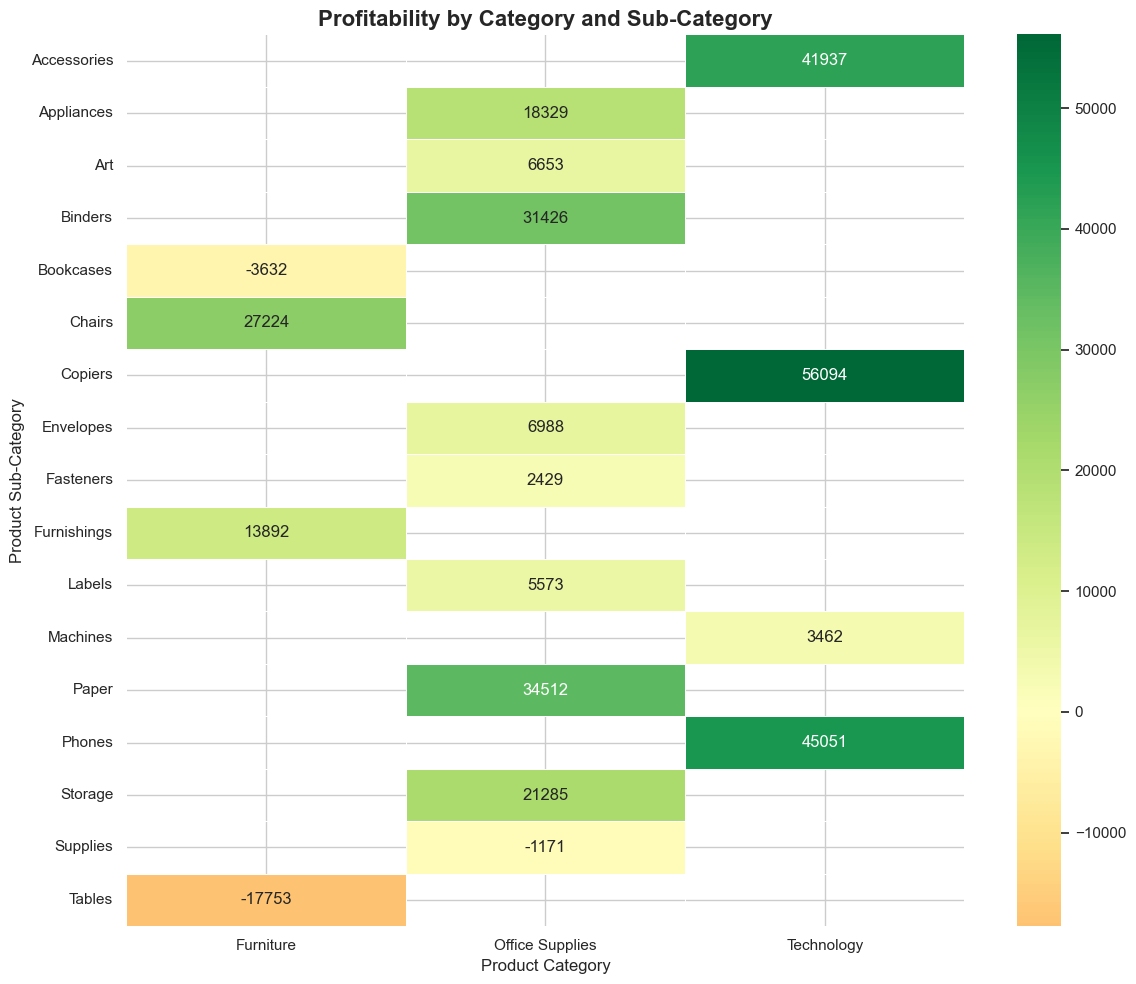

In [52]:
# ==========================================
# Visualization 2: Category × Sub-Category
# Profitability Heatmap
# ==========================================

# Aggregate total profit by Category and Sub-Category
category_subcategory_profit = pd.pivot_table(
    df,
    values="Profit",
    index="Sub-Category",
    columns="Category",
    aggfunc="sum"
)

# Create heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    category_subcategory_profit,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title(
    "Profitability by Category and Sub-Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product Category")
plt.ylabel("Product Sub-Category")

plt.tight_layout()
plt.show()

### Insight – Category and Sub-Category Profitability

The heatmap compares profitability across product categories and sub-categories. This makes it possible to identify strong-performing and weak-performing product areas at a more detailed level.

**Why this visualization was selected:**  
A heatmap is effective when multiple category combinations need to be compared simultaneously.

**Business insight:**  
Profitability varies across sub-categories, indicating that product groups do not contribute equally to overall profit.

**Business implication:**  
Management can use this analysis to focus on profitable product groups while investigating low-profit or loss-making sub-categories for pricing, discount, or cost-related improvements.

In [53]:
# Exact profitability insights

subcategory_profit = (
    df.groupby(["Category", "Sub-Category"])["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print("Top 5 Most Profitable Sub-Categories:")
display(subcategory_profit.head(5).to_frame("Total Profit"))

print("\nBottom 5 Sub-Categories by Profit:")
display(subcategory_profit.tail(5).to_frame("Total Profit"))

Top 5 Most Profitable Sub-Categories:


Total Profit
Category        Sub-Category              
Technology      Copiers         56093.9365
                Phones          45050.8265
                Accessories     41936.6357
Office Supplies Paper           34511.5070
                Binders         31426.1003


Bottom 5 Sub-Categories by Profit:


Total Profit
Category        Sub-Category              
Technology      Machines         3461.9769
Office Supplies Fasteners        2428.6358
                Supplies        -1171.3945
Furniture       Bookcases       -3632.0736
                Tables         -17753.2061

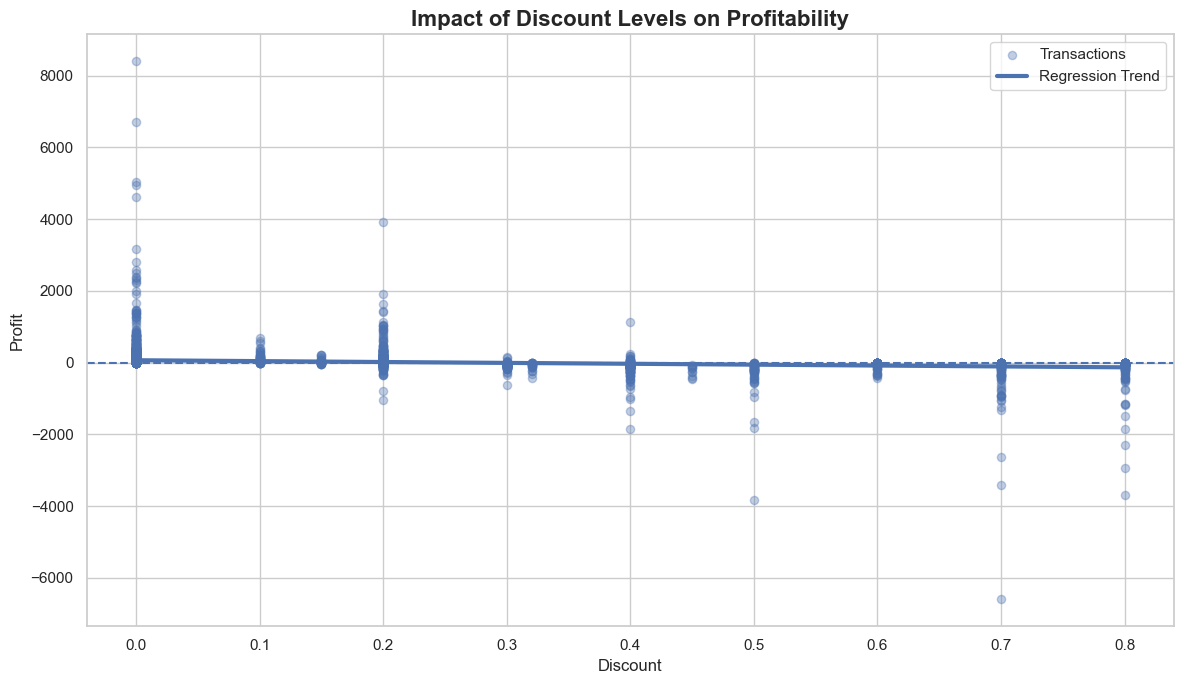

In [54]:
# ==========================================
# Visualization 3: Discount vs Profit
# ==========================================

# Keep only valid numeric observations
discount_profit = df[["Discount", "Profit"]].dropna().copy()

x = discount_profit["Discount"].to_numpy(dtype=float)
y = discount_profit["Profit"].to_numpy(dtype=float)

# Calculate regression line without using np.polyfit
x_mean = x.mean()
y_mean = y.mean()

slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
intercept = y_mean - slope * x_mean

# Predicted values
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

# Plot
plt.figure(figsize=(12, 7))

plt.scatter(
    x,
    y,
    alpha=0.35,
    s=35,
    label="Transactions"
)

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label="Regression Trend"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Impact of Discount Levels on Profitability",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Discount")
plt.ylabel("Profit")

plt.legend()

plt.tight_layout()
plt.show()

### Insight – Discount and Profit Relationship

This regression scatter plot examines the relationship between discount levels and transaction-level profit.

**Why this visualization was selected:**  
A scatter plot with a regression trend is useful for examining relationships between two continuous variables and identifying the overall direction of association.

**Business insight:**  
The analysis shows a negative relationship between discount and profit in the dataset. However, this relationship represents an association and should not be interpreted as proof that discounts directly cause lower profit.

**Business implication:**  
Discount strategies should be evaluated carefully because aggressive discounting may be associated with weaker profitability. Businesses can investigate discount thresholds and product-specific pricing strategies.

In [55]:
# Discount-level profitability summary

discount_summary = (
    df.groupby("Discount")
      .agg(
          Transactions=("Profit", "count"),
          Total_Profit=("Profit", "sum"),
          Average_Profit=("Profit", "mean"),
          Total_Sales=("Sales", "sum")
      )
      .sort_index()
)

display(discount_summary)

,Transactions,Total_Profit,Average_Profit,Total_Sales
Discount,,,,
0.00,4925,326718.5872,66.338799,1.105324e+06
0.10,96,9099.9700,94.791354,5.495250e+04
0.15,52,1418.9915,27.288298,2.755852e+04
0.20,3706,91079.9517,24.576350,7.739394e+05
0.30,230,-10513.4456,-45.710633,1.044741e+05
0.32,27,-2391.1377,-88.560656,1.449346e+04
0.40,207,-23086.3742,-111.528378,1.164978e+05
0.45,11,-2493.1111,-226.646464,5.484974e+03
0.50,66,-20506.4281,-310.703456,5.891854e+04


In [56]:
# Exact top-product performance

top_products_display = top_products[
    ["Product Name", "Category", "Sales", "Profit", "Quantity"]
].sort_values("Sales", ascending=False)

display(top_products_display)

,Product Name,Category,Sales,Profit,Quantity
404,Canon imageCLASS 2200 Advanced Copier,Technology,61599.8240,2.519993e+04,20
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,27453.3840,7.753039e+03,31
444,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.4800,-1.811078e+03,6
785,HON 5400 Series Task Chairs for Big and Tall,Furniture,21870.5760,3.410605e-13,39
685,GBC DocuBind TL300 Electric Binding System,Office Supplies,19823.4790,2.233505e+03,37
687,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,19024.5000,7.609800e+02,48
804,Hewlett Packard LaserJet 3310 Copier,Technology,18839.6860,6.983884e+03,38
786,HP Designjet T520 Inkjet Large Format Printer ...,Technology,18374.8950,4.094977e+03,12
682,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.0680,-1.878166e+03,27
812,High Speed Automatic Electric Letter Opener,Office Supplies,17030.3120,-2.620048e+02,11


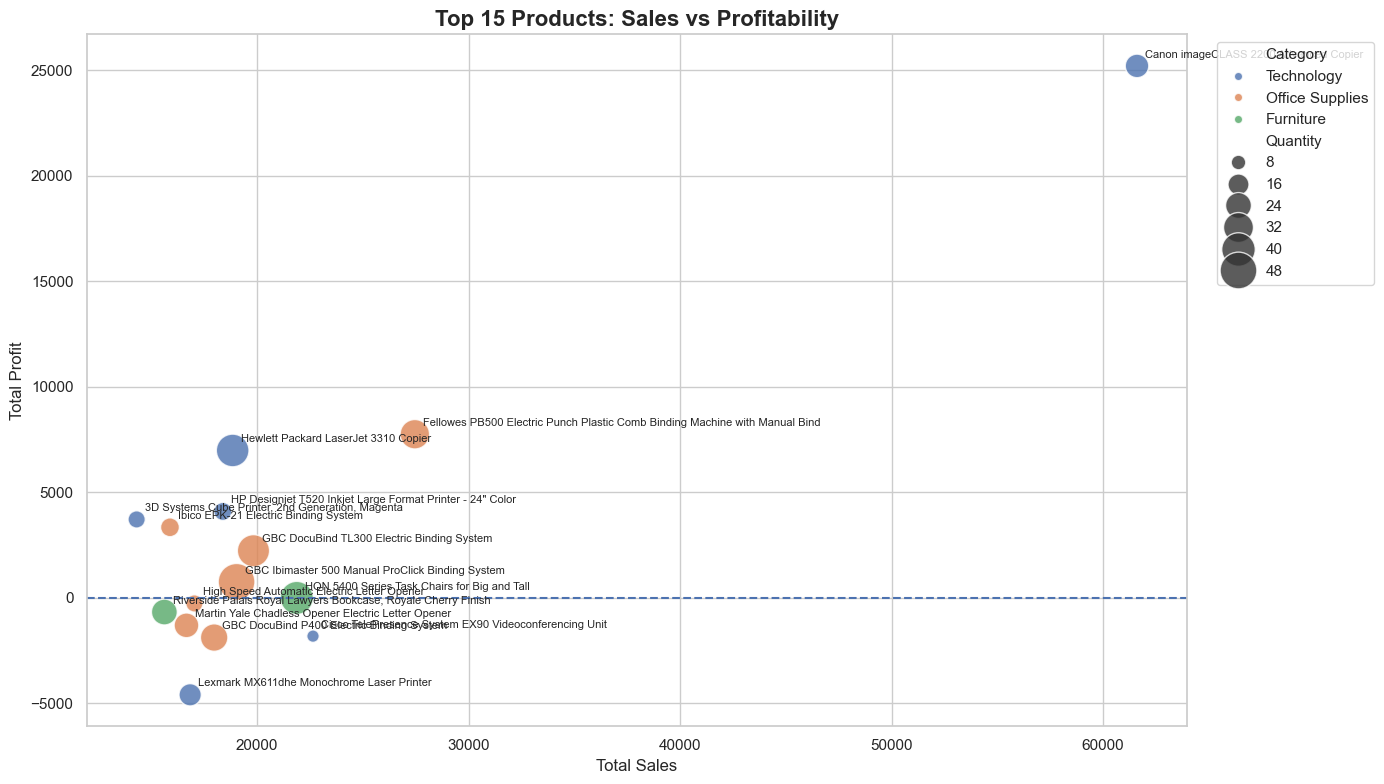

In [57]:
# ==========================================
# Visualization 4: Top Products - Sales vs Profit
# ==========================================

# Aggregate product-level performance
product_summary = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Category=("Category", "first")
      )
      .reset_index()
)

# Select top 15 products by sales
top_products = product_summary.nlargest(15, "Sales").copy()

# Create scatter plot
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=top_products,
    x="Sales",
    y="Profit",
    size="Quantity",
    hue="Category",
    sizes=(80, 700),
    alpha=0.8
)

# Add product labels
for _, row in top_products.iterrows():
    plt.annotate(
        row["Product Name"],
        (row["Sales"], row["Profit"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8
    )

plt.axhline(0, linestyle="--", linewidth=1.5)

plt.title(
    "Top 15 Products: Sales vs Profitability",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Insight – Top Products: Sales versus Profit

This visualization compares the highest-selling products according to both sales and profit. Bubble size represents quantity, while product category provides additional context.

**Why this visualization was selected:**  
A scatter plot allows sales and profit to be compared simultaneously, while bubble size adds a third quantitative dimension.

**Business insight:**  
High sales do not necessarily mean that every product generates equally strong profit. Products should therefore be evaluated using both revenue and profitability metrics.

**Business implication:**  
Product managers can prioritize products that combine strong sales with healthy profitability and investigate high-sales products with relatively weak profit performance.

In [58]:
# Best and weakest profitable products among the top 15 by sales

print("Top 5 by Profit:")
display(
    top_products.nlargest(5, "Profit")[
        ["Product Name", "Category", "Sales", "Profit", "Quantity"]
    ]
)

print("\nLowest 5 by Profit:")
display(
    top_products.nsmallest(5, "Profit")[
        ["Product Name", "Category", "Sales", "Profit", "Quantity"]
    ]
)

Top 5 by Profit:


,Product Name,Category,Sales,Profit,Quantity
404,Canon imageCLASS 2200 Advanced Copier,Technology,61599.824,25199.9280,20
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,27453.384,7753.0390,31
804,Hewlett Packard LaserJet 3310 Copier,Technology,18839.686,6983.8836,38
786,HP Designjet T520 Inkjet Large Format Printer ...,Technology,18374.895,4094.9766,12
19,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,14299.890,3717.9714,11



Lowest 5 by Profit:


,Product Name,Category,Sales,Profit,Quantity
984,Lexmark MX611dhe Monochrome Laser Printer,Technology,16829.9010,-4589.9730,18
682,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.0680,-1878.1662,27
444,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.4800,-1811.0784,6
1042,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,16656.2000,-1299.1836,22
1350,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,15610.9656,-669.5448,24


In [59]:
# ==========================================
# Visualization 5: Regional Performance
# ==========================================

# Calculate regional metrics
regional_summary = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

# Calculate profit margin
regional_summary["Profit Margin (%)"] = (
    regional_summary["Profit"] / regional_summary["Sales"] * 100
)

# Sort by Sales
regional_summary = regional_summary.sort_values(
    "Sales",
    ascending=False
)

display(regional_summary)

,Region,Sales,Profit,Quantity,Profit Margin (%)
3,West,739813.6085,110798.8170,12466,14.976585
1,East,691828.1680,94883.2603,11159,13.714859
0,Central,503170.6728,39865.3070,8820,7.922820
2,South,391721.9050,46749.4303,6209,11.934342


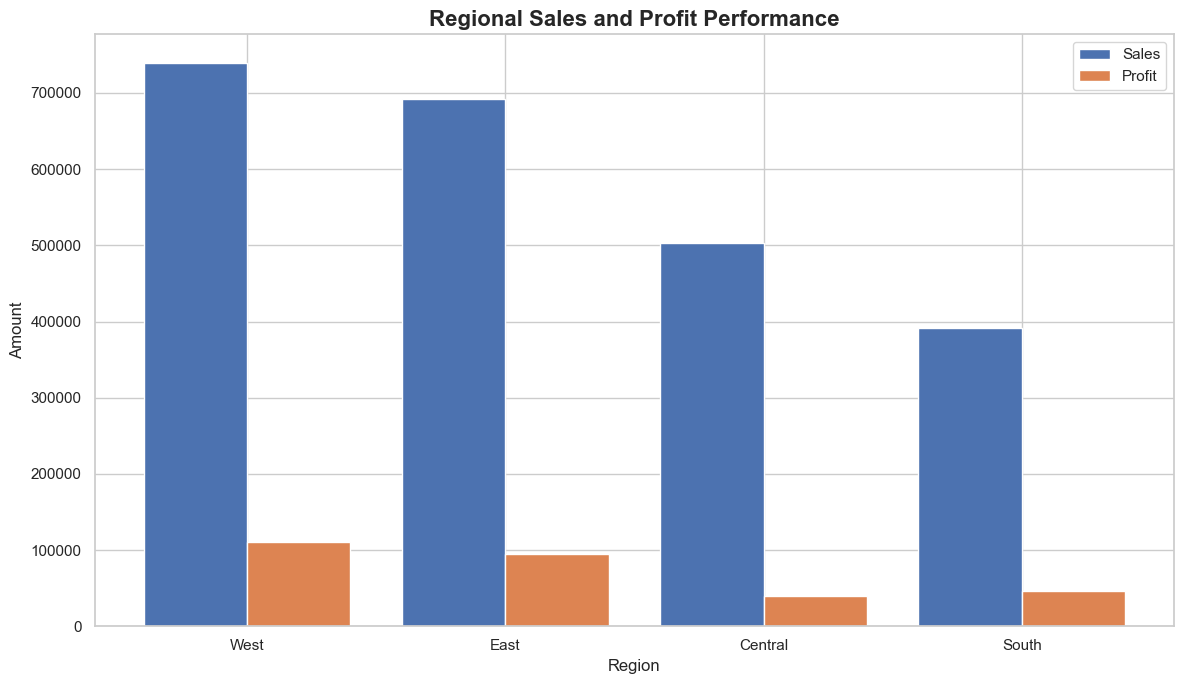

In [60]:
# ==========================================
# Regional Sales vs Profit
# ==========================================

fig, ax1 = plt.subplots(figsize=(12, 7))

x = np.arange(len(regional_summary))

# Sales bars
ax1.bar(
    x - 0.2,
    regional_summary["Sales"],
    width=0.4,
    label="Sales"
)

# Profit bars
ax1.bar(
    x + 0.2,
    regional_summary["Profit"],
    width=0.4,
    label="Profit"
)

ax1.set_xlabel("Region")
ax1.set_ylabel("Amount")
ax1.set_title(
    "Regional Sales and Profit Performance",
    fontsize=16,
    fontweight="bold"
)

ax1.set_xticks(x)
ax1.set_xticklabels(regional_summary["Region"])

ax1.legend()

plt.tight_layout()
plt.show()

### Insight – Regional Sales, Profit and Profit Margin

The regional analysis compares total sales, total profit, and profit margin across geographical regions.

**Why this visualization was selected:**  
Combining sales, profit, and margin provides a more complete view of regional business performance than examining sales alone.

**Business insight:**  
Regional performance differs across the dataset. A region with high sales is not necessarily the region with the highest profitability efficiency.

**Business implication:**  
Regional managers can use profit margin alongside sales to evaluate business efficiency, identify improvement opportunities, and make better resource-allocation decisions.

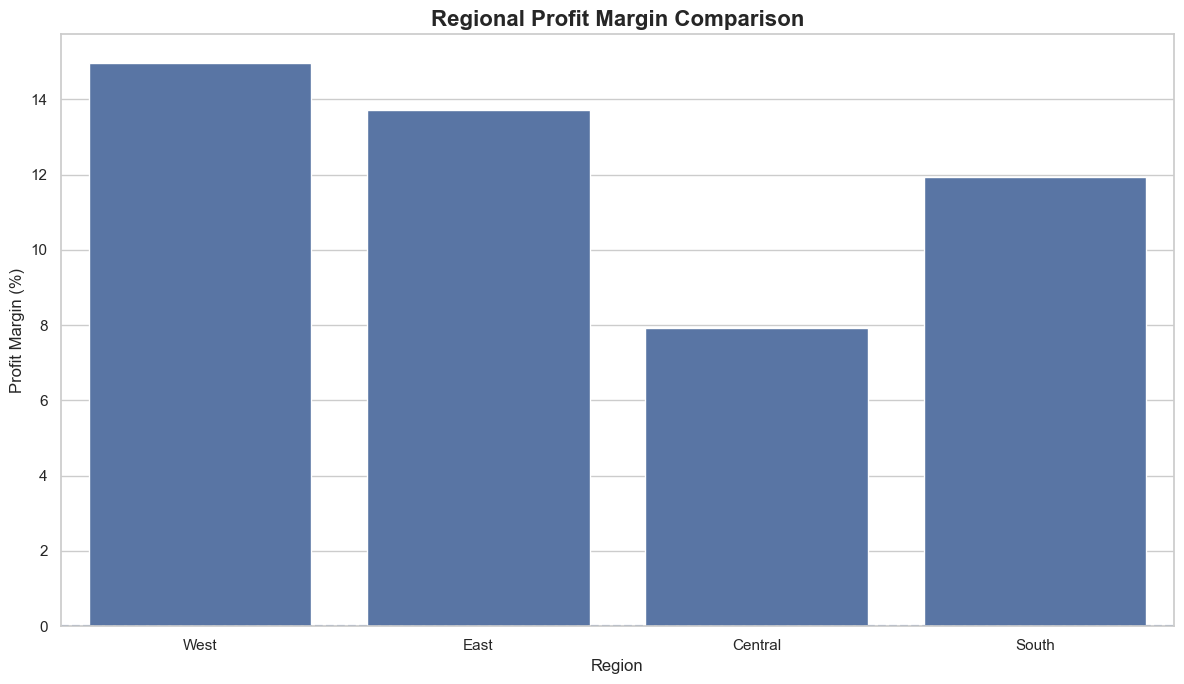

In [61]:
# ==========================================
# Regional Profit Margin
# ==========================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=regional_summary,
    x="Region",
    y="Profit Margin (%)"
)

plt.axhline(0, linestyle="--", linewidth=1.5)

plt.title(
    "Regional Profit Margin Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

In [62]:
# ==========================================
# Regional Insights
# ==========================================

print("Highest Sales Region:")
display(
    regional_summary.nlargest(1, "Sales")[
        ["Region", "Sales", "Profit", "Profit Margin (%)"]
    ]
)

print("\nHighest Profit Region:")
display(
    regional_summary.nlargest(1, "Profit")[
        ["Region", "Sales", "Profit", "Profit Margin (%)"]
    ]
)

print("\nHighest Profit Margin Region:")
display(
    regional_summary.nlargest(1, "Profit Margin (%)")[
        ["Region", "Sales", "Profit", "Profit Margin (%)"]
    ]
)

print("\nLowest Profit Margin Region:")
display(
    regional_summary.nsmallest(1, "Profit Margin (%)")[
        ["Region", "Sales", "Profit", "Profit Margin (%)"]
    ]
)

Highest Sales Region:


,Region,Sales,Profit,Profit Margin (%)
3,West,739813.6085,110798.817,14.976585



Highest Profit Region:


,Region,Sales,Profit,Profit Margin (%)
3,West,739813.6085,110798.817,14.976585



Highest Profit Margin Region:


,Region,Sales,Profit,Profit Margin (%)
3,West,739813.6085,110798.817,14.976585



Lowest Profit Margin Region:


,Region,Sales,Profit,Profit Margin (%)
0,Central,503170.6728,39865.307,7.92282


# 3. Overall Story and Conclusion

The advanced visualization analysis transforms the Superstore Sales dataset into a business-oriented visual story.

The monthly trend analysis demonstrates how business performance changes over time. The category and sub-category heatmap reveals differences in profitability across product groups. The discount-profit analysis highlights an important negative association that warrants further investigation. The product-level analysis demonstrates that sales volume and profitability should be evaluated together rather than independently. Finally, regional analysis shows why sales, profit, and profit margin should be considered together when evaluating geographical performance.

Overall, the analysis demonstrates that effective data visualization is not simply about creating attractive charts. The purpose is to select appropriate visual methods, communicate patterns clearly, and translate those patterns into meaningful business insights.

The findings can support better decisions related to product management, discount strategy, regional performance, profitability monitoring, and business planning.